<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Артём! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

# Предсказание возрастной категории пользователей по истории посещения сайтов

Автор: Мельников Артём Владимирович

Дата: 09.04.2026

# Цели и задачи проекта

Цель проекта - построить модель многоклассовой классификации, которая по данным о поведении анонимного пользователя в интернете предсказывает его возрастную категорию.

В рамках проекта необходимо решить следующие задачи:

- изучить и подготовить данные из нескольких источников;
- объединить таблицы в единое признаковое пространство;
- провести исследовательский анализ данных;
- сформировать информативные признаки на основе логов посещений;
- обучить и сравнить несколько моделей классификации;
- подобрать гиперпараметры лучшей модели;
- сохранить модель и артефакты предобработки для дальнейшего использования.

# Критерий успеха

Проект считается успешным, если выполняются следующие условия:

- значение F1 macro не ниже 0.75 на кросс-валидации;
- значение F1 macro не ниже 0.75 на тестовой выборке;
- модель корректно работает со всеми возрастными категориями, включая менее представленные классы;
- при подготовке данных и обучении исключена утечка информации;
- результаты воспроизводимы, а модель может быть использована вне ноутбука.

# Описание данных

В проекте используются данные о поведении пользователей в цифровой среде. Источники содержат информацию о возрастной категории пользователя, истории посещения сайтов, активности взаимодействия с рекламой, глубине просмотра страниц, основном устройстве и использовании облачных сервисов.

Целевая переменная - `age_category`, отражающая возрастную группу пользователя:

- `0` - младше 18 лет;
- `1` - 18-25 лет;
- `2` - 26-40 лет;
- `3` - 41-55 лет;
- `4` - 56+ лет.

Таким образом, задача относится к многоклассовой классификации.

# Состав данных

В проекте используются следующие таблицы:

- `ds_s13_users.csv` - идентификатор пользователя и возрастная категория;
- `ds_s13_visits.csv` - лог посещений сайтов: дата, время суток, идентификатор сессии, пользователь и категория сайта;
- `ads_activity.csv` - активность взаимодействия пользователя с рекламой;
- `surf_depth.csv` - глубина просмотра сайтов в рамках сессий;
- `primary_device.csv` - основное устройство пользователя для выхода в интернет;
- `cloud_usage.csv` - признак использования облачных технологий.

Основным источником для генерации новых признаков является лог посещений сайтов, так как именно он отражает поведенческие паттерны пользователей.

# План работы

Работа над проектом выполняется в несколько этапов:

1. Подготовка среды и библиотек.
2. Исследовательский анализ данных.
3. Предобработка данных.
4. Обучение и оценка базовой модели.
5. Создание и отбор признаков.
6. Подбор гиперпараметров моделей.
7. Подготовка артефактов модели для внедрения.
8. Формулировка итоговых выводов.

**Ожидаемый результат:**

По итогам проекта должны быть получены:

- обученная модель, способная определять возрастную категорию пользователя по его поведению;
- информативные признаки, отражающие интересы и активность пользователей;
- воспроизводимый пайплайн обработки данных и обучения модели;
- сохраненные артефакты модели, готовые к дальнейшему использованию.

---

# Структура проекта



## Подготовка среды и библиотек

На этом этапе подключим необходимые библиотеки, зафиксируем константы проекта, настроим отображение таблиц и графиков, а также загрузим исходные данные для дальнейшего анализа.

In [1]:
# Установка фиксированных версий библиотек

!pip install -q \
pandas==2.2.2 \
numpy==1.26.4 \
joblib==1.4.2 \
scikit-learn==1.6.1 \
matplotlib==3.8.4 \
seaborn==0.13.2 \
phik==0.12.4 \
category-encoders==2.6.3 \
scipy==1.11.4

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.56.0 requires numpy<1.23,>=1.18, but you have numpy 1.26.4 which is incompatible.


In [2]:
# Подключим библиотеки после установки зафиксированных версий

try:
    # =====================================
    # Базовые библиотеки
    # =====================================
    import numpy as np
    import pandas as pd
    import joblib
    from time import time
    import sys
    import os
    sys.path.append(os.getcwd())
    

    # =====================================
    # Scipy
    # =====================================
    import scipy

    # =====================================
    # Визуализация
    # =====================================
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns

    # =====================================
    # Корреляции
    # =====================================
    import phik
    from phik.report import plot_correlation_matrix

    # =====================================
    # Кодировщики категорий
    # =====================================
    import category_encoders

    # =====================================
    # Sklearn
    # =====================================
    import sklearn

    from sklearn.compose import ColumnTransformer
    from sklearn.dummy import DummyClassifier
    from sklearn.feature_selection import SequentialFeatureSelector
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import (
        ConfusionMatrixDisplay,
        accuracy_score,
        classification_report,
        confusion_matrix,
        f1_score,
        precision_score,
        recall_score,
    )
    from sklearn.model_selection import (
        GridSearchCV,
        StratifiedKFold,
        cross_validate,
        train_test_split,
    )
    from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import (
        FunctionTransformer,
        OneHotEncoder,
        OrdinalEncoder,
        StandardScaler,
    )
    from sklearn.svm import SVC
    from sklearn.metrics import make_scorer

    print("Библиотеки успешно импортированы")

except ImportError as e:
    print(f"Ошибка импорта библиотек: {e}")

Библиотеки успешно импортированы


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

In [3]:
# Зафиксируем версии библиотек в requirements.txt

requirements = f"""
pandas=={pd.__version__}
numpy=={np.__version__}
joblib=={joblib.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={matplotlib.__version__}
seaborn=={sns.__version__}
phik=={phik.__version__}
category-encoders=={category_encoders.__version__}
scipy=={scipy.__version__}
""".strip()

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements)

print("Файл requirements.txt создан")
print()
print(requirements)

Файл requirements.txt создан

pandas==2.2.2
numpy==1.26.4
joblib==1.4.2
scikit-learn==1.6.1
matplotlib==3.8.4
seaborn==0.13.2
phik==0.12.4
category-encoders==2.6.3
scipy==1.11.4


In [4]:
# Зафиксируем константы проекта

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
N_JOBS = -1 # задействуем все ядра для вычислений

In [5]:
# Настройка отображения данных и графиков

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)

try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("seaborn")

sns.set_context("notebook")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

%matplotlib inline

print("Настройки отображения успешно применены")

Настройки отображения успешно применены


In [6]:
# Вспомогательная функция для подписей над столбцами на графиках

def add_bar_labels(ax, fmt="{:.3f}", offset=0.0):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height + offset),
            ha="center",
            va="bottom"
        )

In [7]:
# Загрузка исходных данных

BASE_URL = "https://code.s3.yandex.net/datasets/"

users = pd.read_csv(BASE_URL + "ds_s13_users.csv")
visits = pd.read_csv(BASE_URL + "ds_s13_visits.csv")
ads_activity = pd.read_csv(BASE_URL + "ads_activity.csv")
surf_depth = pd.read_csv(BASE_URL + "surf_depth.csv")
primary_device = pd.read_csv(BASE_URL + "primary_device.csv")
cloud_usage = pd.read_csv(BASE_URL + "cloud_usage.csv")

In [8]:
# Соберем датасеты в словарь для удобного первичного осмотра

datasets = {
    "users": users,
    "visits": visits,
    "ads_activity": ads_activity,
    "surf_depth": surf_depth,
    "primary_device": primary_device,
    "cloud_usage": cloud_usage,
}

In [9]:
# Посмотрим на размеры таблиц и первые строки

for name, df in datasets.items():
    print(f"{name}: {df.shape}")
    display(df.head())
    print()

users: (5913, 2)


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0



visits: (1065745, 5)


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05



ads_activity: (5826, 2)


...

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко



primary_device: (5669, 2)


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК



cloud_usage: (5680, 2)


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


In [10]:
# Изучим общую информацию о таблицах

for name, df in datasets.items():
    print(f"Информация по таблице {name}")
    print("-" * 50)
    df.info()
    print()

Информация по таблице users
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB

Информация по таблице visits
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB

Информация по таблице ads

In [11]:
# Проверим явные дубликаты

for name, df in datasets.items():
    print(f"{name} - полных дубликатов: {df.duplicated().sum()}")

users - полных дубликатов: 87
visits - полных дубликатов: 15750
ads_activity - полных дубликатов: 233
surf_depth - полных дубликатов: 0
primary_device - полных дубликатов: 0
cloud_usage - полных дубликатов: 0


In [12]:
# Проверим дубликаты по user_id там, где это уместно

for name, df in datasets.items():
    if "user_id" in df.columns:
        print(f"{name} - дубликатов по user_id: {df.duplicated(subset='user_id').sum()}")

users - дубликатов по user_id: 87
visits - дубликатов по user_id: 1059919
ads_activity - дубликатов по user_id: 233
surf_depth - дубликатов по user_id: 0
primary_device - дубликатов по user_id: 0
cloud_usage - дубликатов по user_id: 0


**Выводы по разделу**

На данном этапе были установлены и подключены необходимые библиотеки, зафиксированы их версии, заданы константы проекта и настроено отображение таблиц и графиков в Jupyter Notebook. После этого были загружены все исходные датасеты и выполнен их первичный осмотр.

Предварительная проверка показала, что структура таблиц соответствует описанию из задания: основной целевой признак содержится в таблице `users`, а остальные таблицы содержат дополнительные пользовательские характеристики и лог посещений сайтов. Также на этапе первичного осмотра были выявлены явные дубликаты, к которым нужно будет вернуться в ходе дальнейшего анализа данных.

Отдельно отметим, что повторения `user_id` в таблице `visits` ожидаемы, поскольку один пользователь может иметь много записей о посещениях. Для пользовательских таблиц такие повторы уже требуют дополнительной проверки. Далее перейдем к исследовательскому анализу данных, чтобы подробнее изучить состав признаков, распределения и особенности качества данных.

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

## Исследовательский анализ данных

На этом этапе изучим структуру исходных таблиц, определим логику их объединения, проверим данные на дубликаты и пропуски, а также исследуем распределения признаков и целевой переменной. Отдельное внимание уделим таблице логов `visits`, так как именно на ее основе будут формироваться поведенческие признаки пользователя.

У нас есть 6 таблиц, которые можно разделить на несколько логических групп.

1. Целевая таблица `users`  
   Содержит идентификатор пользователя и целевой признак `age_category`, который необходимо предсказывать.

2. Таблица логов `visits`  
   Это самая крупная таблица в проекте. Она содержит историю посещений сайтов, время активности и идентификаторы сессий. Поскольку один пользователь встречается в ней много раз, присоединять ее к остальным данным напрямую нельзя. Сначала необходимо агрегировать логи до уровня одного пользователя.

3. Дополнительные пользовательские признаки  
   Таблицы `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage` содержат дополнительные характеристики пользователей. Так как число строк в них меньше, чем в `users`, для части пользователей значения будут отсутствовать.

Стратегия объединения будет следующей:
- за основу берется таблица `users`;
- данные из `visits` агрегируются до одной строки на пользователя;
- после этого все таблицы объединяются по ключу `user_id`;
- итоговый датасет должен содержать по одной строке на каждого пользователя из целевой таблицы.

In [13]:
# Удалим полные дубликаты в целевой таблице users

users_rows_before = users.shape[0]
users = users.drop_duplicates()
users_rows_after = users.shape[0]

print(f"Удалено полных дубликатов в users: {users_rows_before - users_rows_after}")
print(f"Осталось дубликатов по user_id в users: {users.duplicated(subset='user_id').sum()}")

Удалено полных дубликатов в users: 87
Осталось дубликатов по user_id в users: 0


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [14]:
# Удалим полные дубликаты в таблице логов visits

visits_rows_before = visits.shape[0]
visits = visits.drop_duplicates()
visits_rows_after = visits.shape[0]

print(f"Удалено полных дубликатов в visits: {visits_rows_before - visits_rows_after}")

Удалено полных дубликатов в visits: 15750


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Таблица `visits` содержит повторяющиеся `user_id`, и это ожидаемо, так как один пользователь может совершать много посещений. Поэтому далее перейдем к агрегации логов и построению пользовательских признаков.

In [15]:
# Подготовим агрегированные признаки по логам посещений

visits_by_category = visits.pivot_table(
    index="user_id",
    columns="website_category",
    values="session_id",
    aggfunc="count",
    fill_value=0
)

visits_by_daytime = visits.pivot_table(
    index="user_id",
    columns="daytime",
    values="session_id",
    aggfunc="count",
    fill_value=0
)

user_activity = visits.groupby("user_id").agg(
    total_visits=("session_id", "count"),
    unique_days_count=("date", "nunique")
)

display(visits_by_category.head())
display(visits_by_daytime.head())
display(user_activity.head())

website_category,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20
user_id,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,16,0,34,23,18,29,26,41,13,22,31,43,12,19,15,33,28,43,50,50
0013-4ae5f7d127b91a3fb0f8-ba59f141,15,11,5,7,15,7,9,18,11,11,13,0,12,7,3,8,12,16,1,4
0014-d3032d60979a8d2b3077-f09bdce8,1,2,4,7,8,6,5,2,4,6,0,7,20,8,7,2,9,3,12,4
001a-eee53e44f848608779b0-78704a67,19,13,10,22,10,9,12,13,13,12,14,19,0,28,12,9,13,21,21,17
002c-40a064b12e1217e12207-a56eaf3b,0,26,35,30,20,19,29,9,29,32,19,42,83,0,22,20,17,6,25,27


daytime,вечер,день,ночь,утро
user_id,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,226,178,52,90
0013-4ae5f7d127b91a3fb0f8-ba59f141,51,69,16,49
0014-d3032d60979a8d2b3077-f09bdce8,36,45,11,25
001a-eee53e44f848608779b0-78704a67,119,96,31,41
002c-40a064b12e1217e12207-a56eaf3b,145,188,34,123


,total_visits,unique_days_count
user_id,,
0010-5cf8f6b38a7b6c70a021-009dbcda,546,14
0013-4ae5f7d127b91a3fb0f8-ba59f141,185,14
0014-d3032d60979a8d2b3077-f09bdce8,117,14
001a-eee53e44f848608779b0-78704a67,287,14
002c-40a064b12e1217e12207-a56eaf3b,490,14


In [16]:
# Объединим агрегированные признаки из visits в одну таблицу

visits_features = user_activity.join([visits_by_category, visits_by_daytime])

print(f"Размер агрегированной таблицы visits_features: {visits_features.shape}")
display(visits_features.head())

Размер агрегированной таблицы visits_features: (5826, 26)


,total_visits,unique_days_count,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,вечер,день,ночь,утро
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,546,14,16,0,34,23,18,29,26,41,13,22,31,43,12,19,15,33,28,43,50,50,226,178,52,90
0013-4ae5f7d127b91a3fb0f8-ba59f141,185,14,15,11,5,7,15,7,9,18,11,11,13,0,12,7,3,8,12,16,1,4,51,69,16,49
0014-d3032d60979a8d2b3077-f09bdce8,117,14,1,2,4,7,8,6,5,2,4,6,0,7,20,8,7,2,9,3,12,4,36,45,11,25
001a-eee53e44f848608779b0-78704a67,287,14,19,13,10,22,10,9,12,13,13,12,14,19,0,28,12,9,13,21,21,17,119,96,31,41
002c-40a064b12e1217e12207-a56eaf3b,490,14,0,26,35,30,20,19,29,9,29,32,19,42,83,0,22,20,17,6,25,27,145,188,34,123


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично!  Развернули visits.</font>

In [17]:
# В ads_activity удалим повторяющиеся user_id, оставив по одной записи на пользователя

ads_rows_before = ads_activity.shape[0]
ads_activity = ads_activity.drop_duplicates(subset="user_id")
ads_rows_after = ads_activity.shape[0]

print(f"Удалено дубликатов по user_id в ads_activity: {ads_rows_before - ads_rows_after}")

Удалено дубликатов по user_id в ads_activity: 233


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [18]:
# Объединим все таблицы в единый датасет
# За основу берем users, чтобы сохранить целевую выборку пользователей

data = (
    users.set_index("user_id")
    .join([
        visits_features,
        ads_activity.set_index("user_id"),
        surf_depth.set_index("user_id"),
        primary_device.set_index("user_id"),
        cloud_usage.set_index("user_id"),
    ])
)

print(f"Размер итогового датасета после объединения: {data.shape}")
display(data.head(10))

Размер итогового датасета после объединения: (5826, 31)


,age_category,total_visits,unique_days_count,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,вечер,день,ночь,утро,ads_activity,surf_depth,primary_device,cloud_usage
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f545-8c95aefe8d3e5548a689-a5b2fd39,4,187,14,12,7,7,11,19,4,0,9,19,5,14,3,6,7,10,8,11,13,14,8,63,67,14,43,NaN,глубоко,смартфон,False
cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,141,14,9,6,14,3,8,5,15,15,6,10,6,6,5,0,9,5,5,4,5,5,55,48,13,25,умеренно,средне,смартфон,False
678b-614cd47d854b9d591db2-000b2e50,0,100,14,1,7,0,11,7,13,0,4,0,1,3,15,12,1,2,3,2,1,11,6,38,29,13,20,умеренно,средне,смартфон,False
4ac0-dad169100b4a29b20818-b26ae7c5,4,248,14,20,1,25,7,27,12,7,16,15,0,16,4,19,5,6,7,16,33,9,3,64,109,18,57,редко,поверхностно,смартфон,True
f19b-9ac21ca973b41ecfa8c3-6a58191d,0,119,14,8,5,11,4,6,1,6,8,9,5,5,15,0,10,3,3,6,4,3,7,50,41,9,19,очень редко,поверхностно,смартфон,True
348c-35488a73fb49d5b0449e-1920481e,0,100,14,8,1,9,8,1,6,5,5,3,1,0,8,0,13,7,5,0,9,6,5,48,27,15,10,умеренно,поверхностно,смартфон,False
f3cd-a32250aea93b5a3d6e48-2f6d3c21,2,256,14,13,11,8,17,19,18,4,27,10,15,13,15,0,16,20,11,7,10,13,9,74,109,24,49,умеренно,средне,ноутбук,False
d289-e3226cd63d5718a55b6e-4fcb65c0,4,247,14,10,11,4,14,21,19,2,13,17,6,9,13,20,16,19,2,22,0,11,18,85,101,11,50,умеренно,средне,ноутбук,True
b5ff-7828dbb91d99930fcc3f-48617440,4,219,14,0,4,2,19,11,8,8,2,17,15,7,19,31,11,17,5,21,8,5,9,63,92,12,52,умеренно,поверхностно,смартфон,True


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно, при объединении таблиц нужно привязаться к уникальному `'user_id'`.</font>

In [19]:
# Общая информация по итоговому датасету

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, f545-8c95aefe8d3e5548a689-a5b2fd39 to c892-72c57d41488d7956d880-3474e42b
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age_category       5826 non-null   int64 
 1   total_visits       5826 non-null   int64 
 2   unique_days_count  5826 non-null   int64 
 3   Category 01        5826 non-null   int64 
 4   Category 02        5826 non-null   int64 
 5   Category 03        5826 non-null   int64 
 6   Category 04        5826 non-null   int64 
 7   Category 05        5826 non-null   int64 
 8   Category 06        5826 non-null   int64 
 9   Category 07        5826 non-null   int64 
 10  Category 08        5826 non-null   int64 
 11  Category 09        5826 non-null   int64 
 12  Category 10        5826 non-null   int64 
 13  Category 11        5826 non-null   int64 
 14  Category 12        5826 non-null   int64 
 15  Category 13        5826 non-nul

In [20]:
# Изучим распределение количества уникальных дней активности

unique_days_stats = data["unique_days_count"].value_counts().sort_index()
unique_days_share = data["unique_days_count"].value_counts(normalize=True).sort_index() * 100

display(unique_days_stats)
display(unique_days_share)

unique_days_count
13       8
14    5818
Name: count, dtype: int64

unique_days_count
13    0.1373
14   99.8627
Name: proportion, dtype: float64

In [21]:
# Если признак почти не меняется, он вряд ли будет полезен модели

data = data.drop(columns=["unique_days_count"])
print("Признак unique_days_count удален из датасета")

Признак unique_days_count удален из датасета


In [22]:
# Оценим количество уникальных значений и типы признаков

feature_overview = pd.DataFrame({
    "unique_count": data.nunique(),
    "dtype": data.dtypes
}).sort_values(by="unique_count")

display(feature_overview)

,unique_count,dtype
cloud_usage,2,object
surf_depth,3,object
primary_device,4,object
age_category,5,int64
ads_activity,5,object
Category 11,43,int64
Category 02,45,int64
Category 15,46,int64
Category 14,48,int64
Category 04,48,int64


In [23]:
# Выделим числовые и категориальные признаки

numeric_features = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = data.select_dtypes(include=["object", "bool"]).columns.tolist()

# Исключим целевой признак из списка числовых
numeric_features.remove("age_category")

print("Числовые признаки:")
print(numeric_features)
print()
print("Категориальные признаки:")
print(categorical_features)

Числовые признаки:
['total_visits', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'вечер', 'день', 'ночь', 'утро']

Категориальные признаки:
['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']


In [24]:
# Посмотрим на распределение целевого признака

target_counts = data["age_category"].value_counts().sort_index()
target_share = data["age_category"].value_counts(normalize=True).sort_index() * 100

display(target_counts)
display(target_share)

age_category
0     853
1     514
2    1439
3    1254
4    1766
Name: count, dtype: int64

age_category
0   14.6413
1    8.8225
2   24.6996
3   21.5242
4   30.3124
Name: proportion, dtype: float64

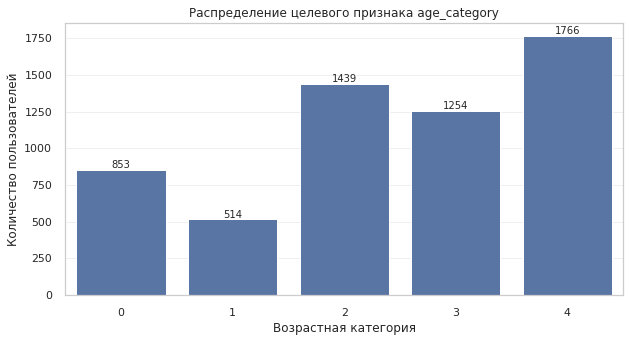

In [25]:
# Визуализируем распределение целевого признака

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=data, x="age_category", order=sorted(data["age_category"].unique()))
add_bar_labels(ax, fmt="{:.0f}")
plt.title("Распределение целевого признака age_category")
plt.xlabel("Возрастная категория")
plt.ylabel("Количество пользователей")
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Нашли дисбаланс.</font>

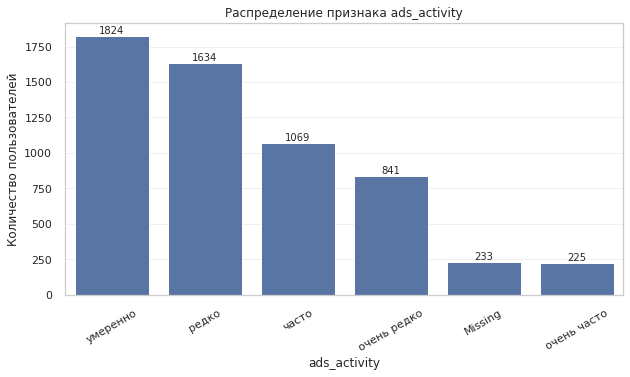

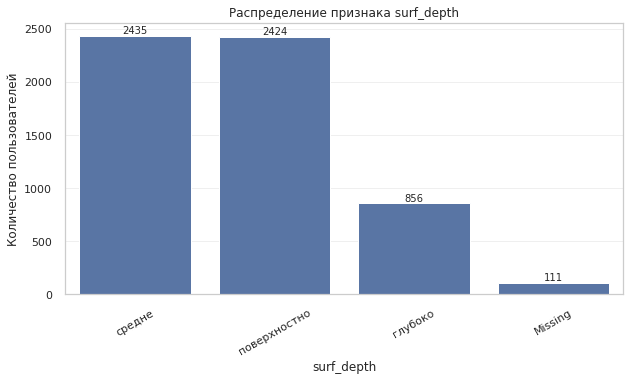

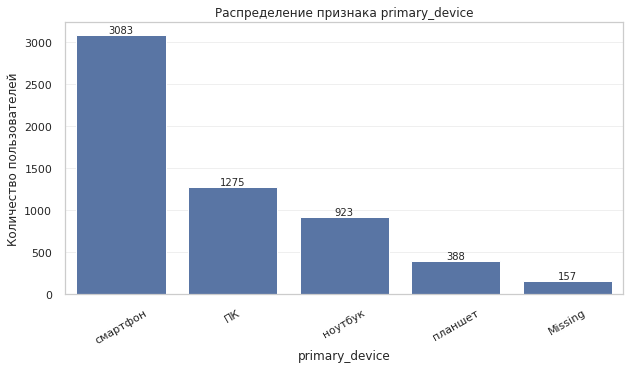

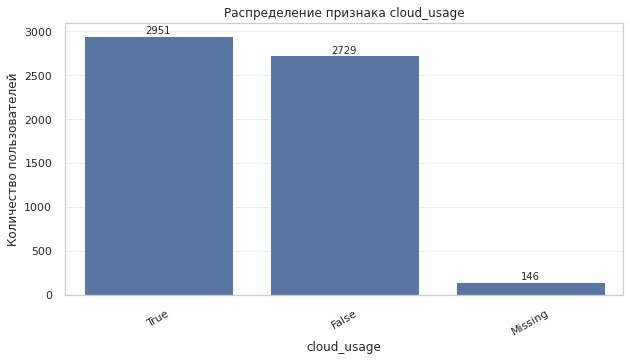

In [26]:
# Визуализируем распределение категориальных признаков

for column in categorical_features:
    plt.figure(figsize=(10, 5))

    temp = data[column].fillna("Missing")

    order = temp.value_counts().index

    ax = sns.countplot(x=temp, order=order)
    add_bar_labels(ax, fmt="{:.0f}")

    plt.title(f"Распределение признака {column}")
    plt.xlabel(column)
    plt.ylabel("Количество пользователей")
    plt.xticks(rotation=30)
    plt.show()

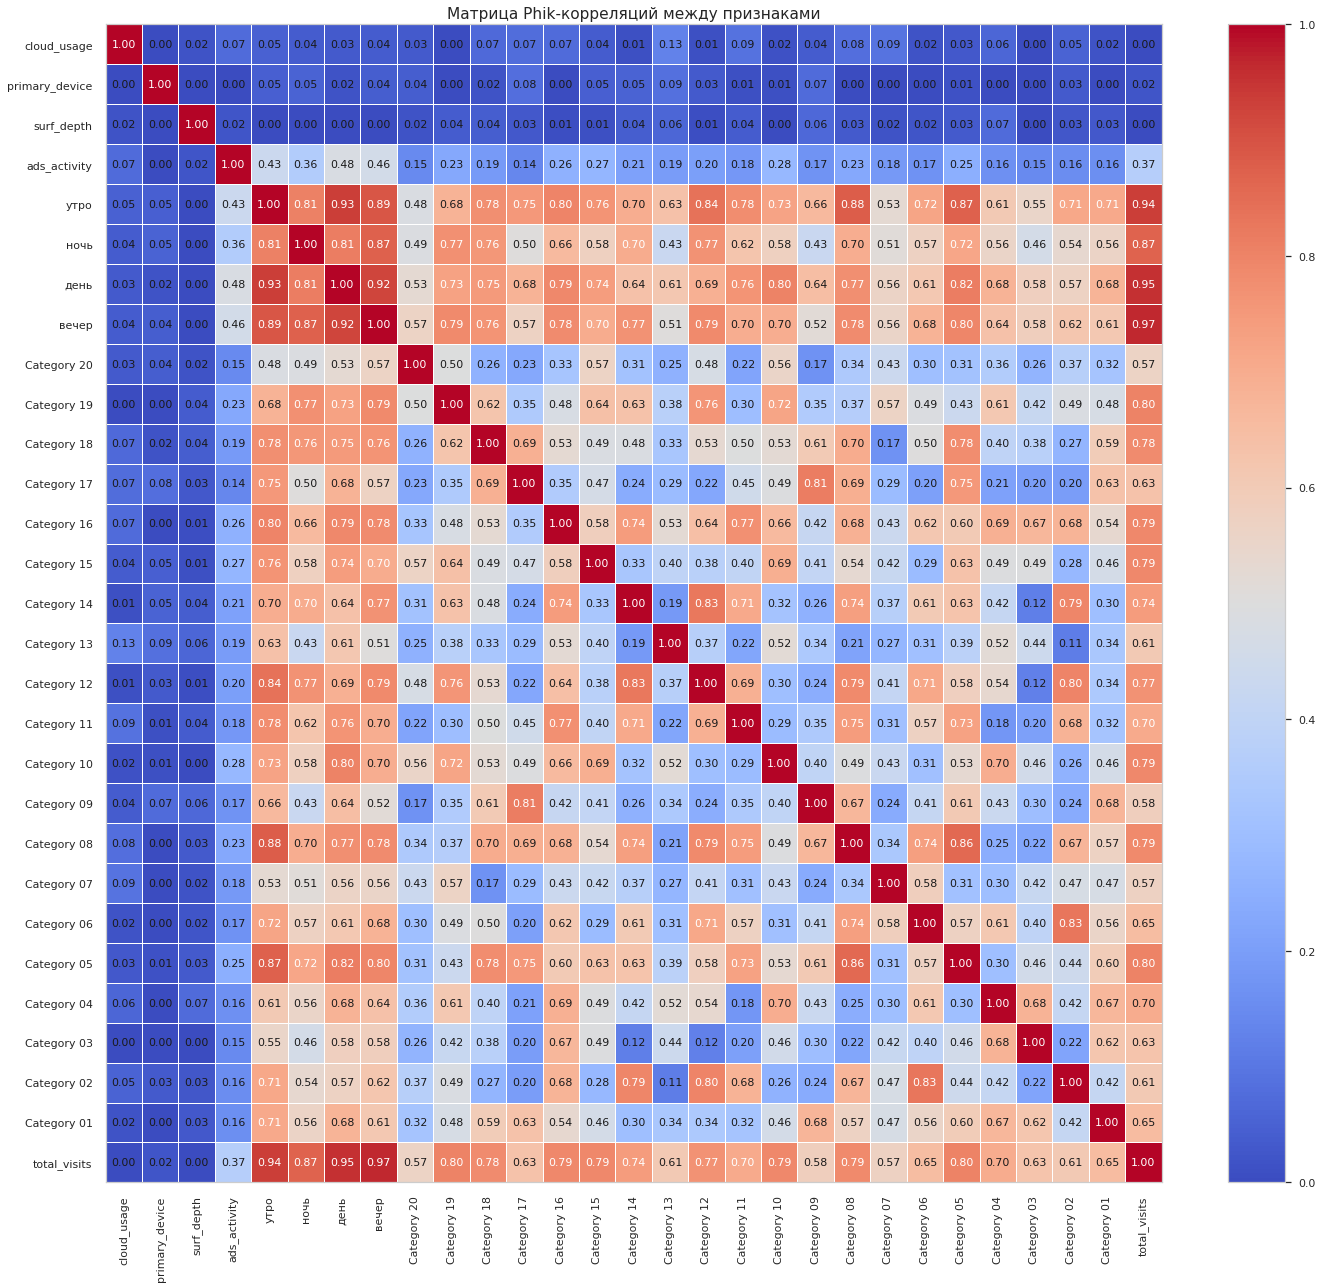

In [27]:
# Оценим связи между признаками с помощью phik
# Сначала исключим целевой признак

data_no_target = data.drop(columns=["age_category"]).copy()

phik_features = data_no_target.phik_matrix(interval_cols=numeric_features)

plot_correlation_matrix(
    phik_features.values,
    x_labels=phik_features.columns,
    y_labels=phik_features.index,
    vmin=0,
    vmax=1,
    color_map="coolwarm",
    title="Матрица Phik-корреляций между признаками",
    fontsize_factor=1.1,
    figsize=(20, 18)
)

plt.tight_layout()
plt.show()

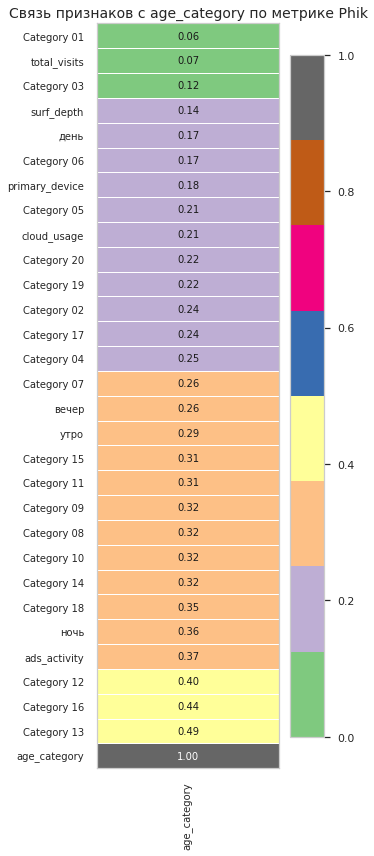

In [28]:
# Оценим связь признаков с целевой переменной

phik_full = data.phik_matrix(interval_cols=numeric_features)
phik_with_target = phik_full[["age_category"]].sort_values(by="age_category", ascending=False)

plot_correlation_matrix(
    phik_with_target.values,
    x_labels=phik_with_target.columns,
    y_labels=phik_with_target.index,
    vmin=0,
    vmax=1,
    color_map="Accent",
    title="Связь признаков с age_category по метрике Phik",
    fontsize_factor=1,
    figsize=(5, 12)
)

plt.show()

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

In [29]:
# Проверим пропуски, пустые строки и значения, состоящие только из пробелов

missing_summary = {}

for column in data.columns:
    missing_count = data[column].isna().sum()

    if data[column].dtype == "object":
        as_string = data[column].astype(str)
        missing_count += (as_string == "").sum()
        missing_count += as_string.str.isspace().sum()
        missing_count += (as_string.str.lower() == "nan").sum()
        missing_count += (as_string.str.lower() == "none").sum()

    if missing_count > 0:
        missing_summary[column] = missing_count

if missing_summary:
    missing_table = (
        pd.DataFrame.from_dict(missing_summary, orient="index", columns=["missing_count"])
        .sort_values(by="missing_count", ascending=False)
    )
    display(missing_table)
else:
    print("Пропуски, пустые строки и пробельные значения не обнаружены")

,missing_count
ads_activity,466
primary_device,314
cloud_usage,292
surf_depth,222


In [30]:
# Проверим, есть ли пользователи, у которых одновременно отсутствуют все дополнительные признаки

columns_with_possible_missing = ["ads_activity", "surf_depth", "primary_device", "cloud_usage"]

all_missing_mask = pd.Series(True, index=data.index)

for column in columns_with_possible_missing:
    col_as_str = data[column].astype(str)
    current_missing = (
        (col_as_str == "") |
        (col_as_str.str.isspace()) |
        (col_as_str.str.lower() == "nan") |
        (col_as_str.str.lower() == "none")
    )
    all_missing_mask &= current_missing

rows_with_all_missing = data[all_missing_mask]

print(f"Количество строк, где отсутствуют все дополнительные признаки: {rows_with_all_missing.shape[0]}")
display(rows_with_all_missing.head())

Количество строк, где отсутствуют все дополнительные признаки: 0


,age_category,total_visits,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,вечер,день,ночь,утро,ads_activity,surf_depth,primary_device,cloud_usage
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


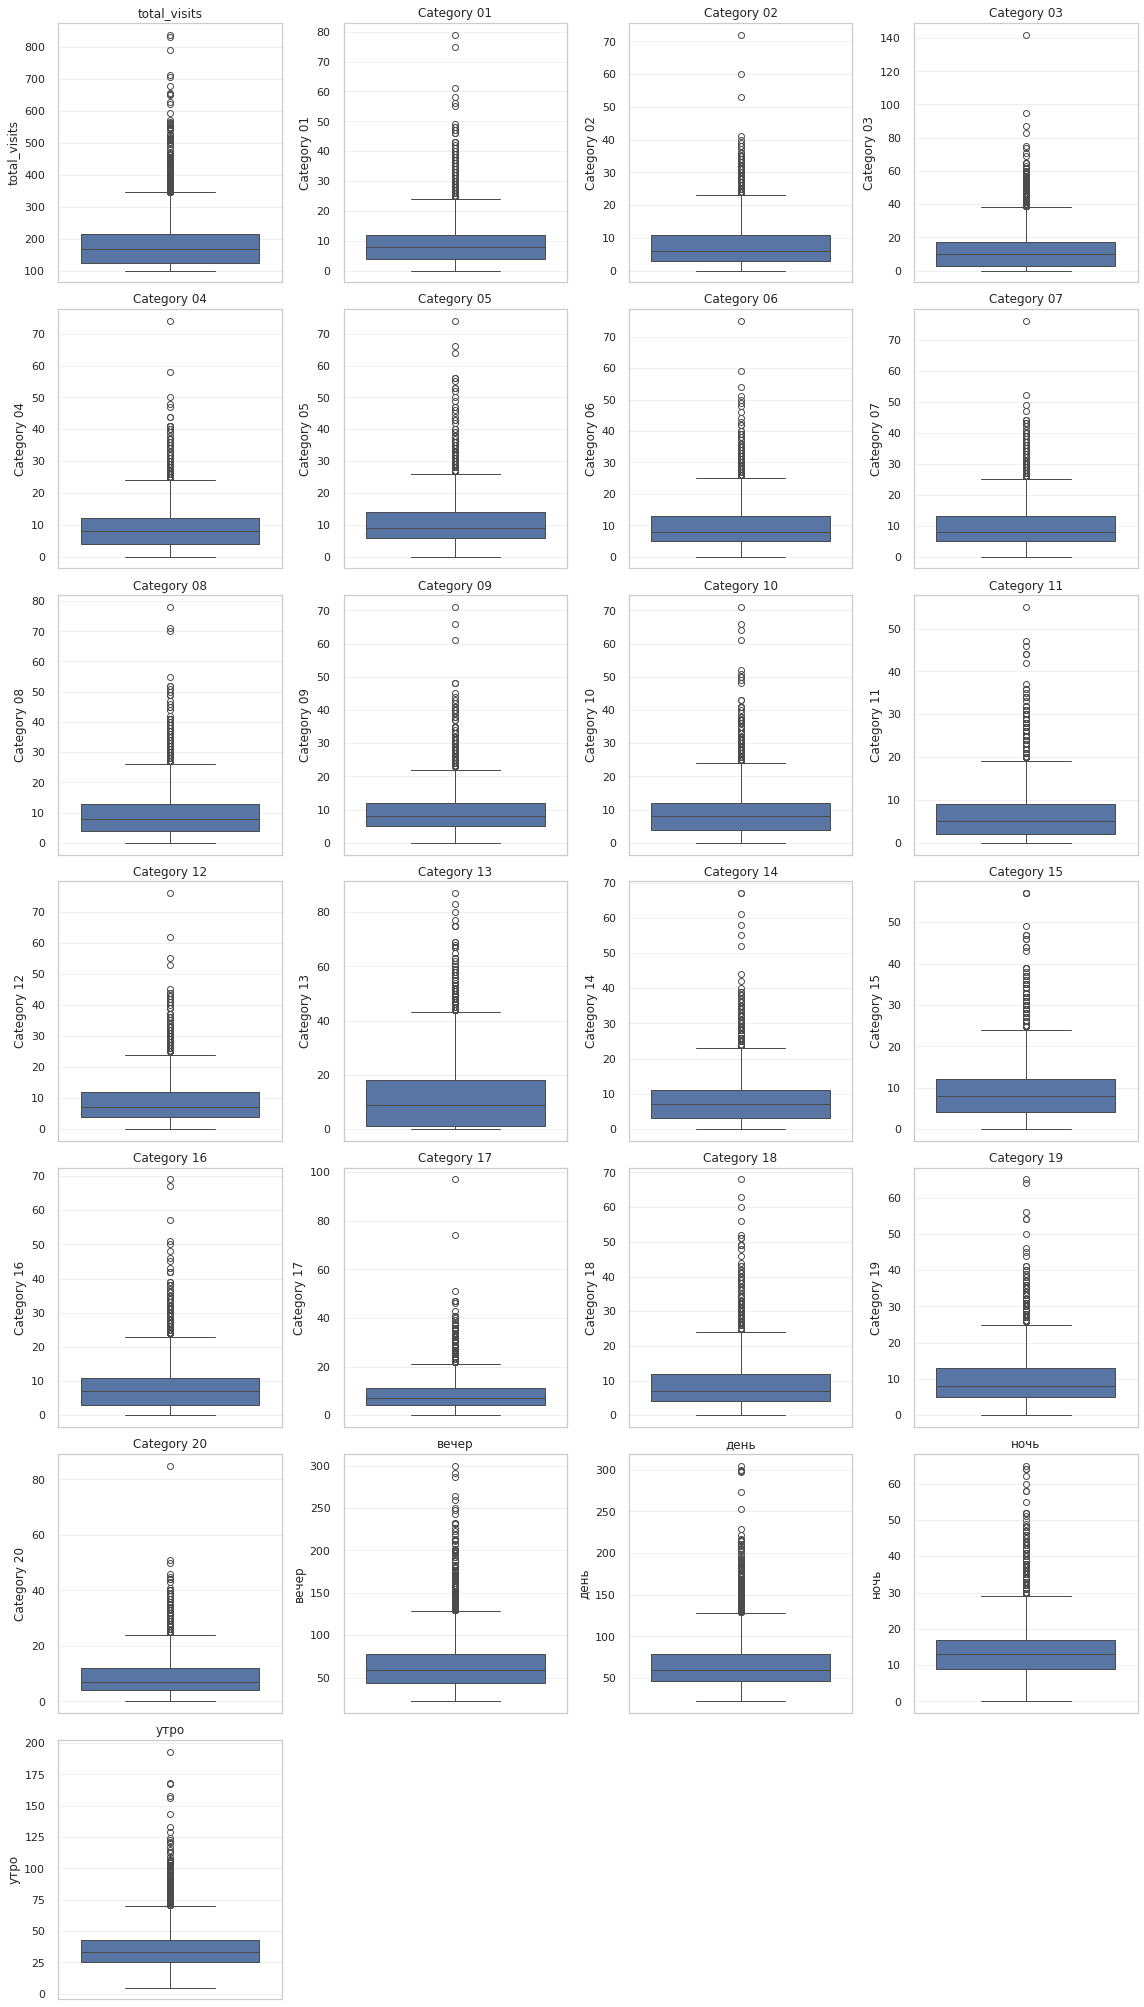

In [31]:
# Посмотрим на распределения числовых признаков через boxplot (ящик с усами)

n_cols = 4
n_rows = (len(numeric_features) - 1) // n_cols + 1

plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, column in enumerate(numeric_features, start=1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [32]:
# Выведем расширенную описательную статистику по числовым признакам

display(
    data[numeric_features].describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.97, 0.99, 0.995]
    ).T
)

,count,mean,std,min,25%,50%,75%,90%,95%,97%,99%,99.5%,max
total_visits,5826.0000,180.2257,75.1868,100.0000,124.0000,167.0000,213.0000,273.0000,322.0000,353.0000,438.7500,510.0000,839.0000
Category 01,5826.0000,8.9943,7.0414,0.0000,4.0000,8.0000,12.0000,18.0000,22.0000,25.0000,31.0000,37.0000,79.0000
Category 02,5826.0000,7.5218,6.3339,0.0000,3.0000,6.0000,11.0000,16.0000,19.0000,22.0000,28.0000,32.0000,72.0000
Category 03,5826.0000,11.8656,11.1895,0.0000,3.0000,10.0000,17.0000,26.0000,33.0000,37.0000,49.0000,55.8750,142.0000
Category 04,5826.0000,8.7662,6.2856,0.0000,4.0000,8.0000,12.0000,17.0000,20.0000,23.0000,29.0000,34.0000,74.0000
Category 05,5826.0000,10.2506,6.8763,0.0000,6.0000,9.0000,14.0000,19.0000,23.0000,26.0000,32.0000,36.0000,74.0000
Category 06,5826.0000,9.6538,6.5315,0.0000,5.0000,8.0000,13.0000,18.0000,22.0000,25.0000,31.0000,35.0000,75.0000
Category 07,5826.0000,9.2527,6.6817,0.0000,5.0000,8.0000,13.0000,18.0000,21.0000,25.0000,31.0000,36.0000,76.0000
Category 08,5826.0000,9.4739,7.1862,0.0000,4.0000,8.0000,13.0000,18.0000,22.0000,25.0000,33.0000,37.8750,78.0000
Category 09,5826.0000,9.1124,6.3510,0.0000,5.0000,8.0000,12.0000,17.0000,21.0000,23.0000,29.0000,33.8750,71.0000


**Выводы по результатам исследовательского анализа данных**

В ходе исследовательского анализа были объединены данные из шести источников. За основу была взята таблица `users`, содержащая целевой признак `age_category`. Логи посещений `visits` были предварительно агрегированы до уровня пользователя, что позволило получить числовые признаки, отражающие интенсивность и структуру интернет-активности.

В таблицах `users`, `visits` и `ads_activity` были обнаружены явные дубликаты, поэтому перед дальнейшим анализом они были удалены. После объединения удалось сформировать единый датасет с одной строкой на пользователя.

Анализ показал, что в дополнительных категориальных признаках присутствуют пропуски: они обнаружены в `ads_activity`, `surf_depth`, `primary_device` и `cloud_usage`. При визуализации распределений пропуски были выделены как отдельная категория `Missing`, что позволило явно оценить их масштаб. При этом строк, в которых одновременно отсутствуют все дополнительные пользовательские признаки, не обнаружено, поэтому удалять объекты на этом этапе не требуется.

Анализ целевой переменной показал, что в выборке представлены все пять возрастных категорий. Наиболее многочисленной является категория `4`, а наименее представленной - категория `1`. Сильного дисбаланса не наблюдается, однако распределение классов нельзя считать полностью равномерным, поэтому при обучении модели важно использовать стратификацию и метрики с макроусреднением.

Изучение распределений числовых признаков показало выраженную асимметрию и наличие пользователей с высокой активностью. Эти значения не выглядят ошибками данных и, скорее всего, отражают реальные различия в поведении пользователей. Поэтому выбросы на данном этапе не удаляются, а для снижения их влияния далее используется переход от абсолютных значений к относительным долям.

Матрица Phik показала, что часть признаков уже на этапе EDA имеет заметную связь с целевой переменной. Наиболее выраженная связь наблюдается у признаков, связанных с категорией сайтов `Category 13`, `Category 16`, `Category 12`, а также с временем активности и рекламной активностью. Это подтверждает, что поведенческие характеристики пользователей действительно могут быть полезны для предсказания возрастной категории.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Хорошая работа в части исследования данных: молодец, что используешь функции, а также применяешь подходящие для типов данных инструменты.</font>

## Предобработка данных

На данном этапе формируется итоговое признаковое пространство для обучения моделей. Основная задача - подготовить данные таким образом, чтобы снизить влияние различий в пользовательской активности, корректно обработать пропуски и построить воспроизводимый пайплайн преобразований без утечки данных.

В частности, будут выполнены следующие шаги:
- переход от абсолютных значений к относительным долям;
- удаление избыточных и мультиколлинеарных признаков;
- разделение данных на обучающую и тестовую выборки;
- группировка признаков по типам;
- построение пайплайнов обработки;
- объединение всех преобразований в единый ColumnTransformer.

### 3.1 Генерация новых признаков

Количество визитов сильно различается между пользователями. Чтобы нивелировать влияние "суперактивных" пользователей и привести данные к единому масштабу, перейдем от абсолютных значений к долям.

Для каждой категории сайтов и времени суток рассчитаем долю активности пользователя от общего числа визитов.

In [33]:
# Определим списки колонок для нормализации

category_columns = data.filter(like="Category").columns.tolist()
time_columns = ["утро", "день", "вечер", "ночь"]

columns_to_normalize = category_columns + time_columns

In [34]:
# Создаем признаки-доли

for column in columns_to_normalize:
    new_column = f"share_{column}"
    data[new_column] = data[column] / data["total_visits"]

data.head()

,age_category,total_visits,Category 01,Category 02,Category 03,Category 04,Category 05,Category 06,Category 07,Category 08,Category 09,Category 10,Category 11,Category 12,Category 13,Category 14,Category 15,Category 16,Category 17,Category 18,Category 19,Category 20,вечер,день,ночь,утро,ads_activity,surf_depth,primary_device,cloud_usage,share_Category 01,share_Category 02,share_Category 03,share_Category 04,share_Category 05,share_Category 06,share_Category 07,share_Category 08,share_Category 09,share_Category 10,share_Category 11,share_Category 12,share_Category 13,share_Category 14,share_Category 15,share_Category 16,share_Category 17,share_Category 18,share_Category 19,share_Category 20,share_утро,share_день,share_вечер,share_ночь
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
f545-8c95aefe8d3e5548a689-a5b2fd39,4,187,12,7,7,11,19,4,0,9,19,5,14,3,6,7,10,8,11,13,14,8,63,67,14,43,NaN,глубоко,смартфон,False,0.0642,0.0374,0.0374,0.0588,0.1016,0.0214,0.0000,0.0481,0.1016,0.0267,0.0749,0.0160,0.0321,0.0374,0.0535,0.0428,0.0588,0.0695,0.0749,0.0428,0.2299,0.3583,0.3369,0.0749
cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,141,9,6,14,3,8,5,15,15,6,10,6,6,5,0,9,5,5,4,5,5,55,48,13,25,умеренно,средне,смартфон,False,0.0638,0.0426,0.0993,0.0213,0.0567,0.0355,0.1064,0.1064,0.0426,0.0709,0.0426,0.0426,0.0355,0.0000,0.0638,0.0355,0.0355,0.0284,0.0355,0.0355,0.1773,0.3404,0.3901,0.0922
678b-614cd47d854b9d591db2-000b2e50,0,100,1,7,0,11,7,13,0,4,0,1,3,15,12,1,2,3,2,1,11,6,38,29,13,20,умеренно,средне,смартфон,False,0.0100,0.0700,0.0000,0.1100,0.0700,0.1300,0.0000,0.0400,0.0000,0.0100,0.0300,0.1500,0.1200,0.0100,0.0200,0.0300,0.0200,0.0100,0.1100,0.0600,0.2000,0.2900,0.3800,0.1300
4ac0-dad169100b4a29b20818-b26ae7c5,4,248,20,1,25,7,27,12,7,16,15,0,16,4,19,5,6,7,16,33,9,3,64,109,18,57,редко,поверхностно,смартфон,True,0.0806,0.0040,0.1008,0.0282,0.1089,0.0484,0.0282,0.0645,0.0605,0.0000,0.0645,0.0161,0.0766,0.0202,0.0242,0.0282,0.0645,0.1331,0.0363,0.0121,0.2298,0.4395,0.2581,0.0726
f19b-9ac21ca973b41ecfa8c3-6a58191d,0,119,8,5,11,4,6,1,6,8,9,5,5,15,0,10,3,3,6,4,3,7,50,41,9,19,очень редко,поверхностно,смартфон,True,0.0672,0.0420,0.0924,0.0336,0.0504,0.0084,0.0504,0.0672,0.0756,0.0420,0.0420,0.1261,0.0000,0.0840,0.0252,0.0252,0.0504,0.0336,0.0252,0.0588,0.1597,0.3445,0.4202,0.0756


### 3.2 Удаление исходных признаков

После создания долей исходные признаки с абсолютными значениями становятся избыточными. Также удаляем признак total_visits, чтобы избежать мультиколлинеарности.

In [35]:
data = data.drop(columns=columns_to_normalize)
data = data.drop(columns=["total_visits"])

print("Исходные количественные признаки удалены")

Исходные количественные признаки удалены


### 3.3 Обновление типов признаков

In [36]:
# Обновим список числовых признаков

numeric_features = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove("age_category")

print(numeric_features[:10])

['share_Category 01', 'share_Category 02', 'share_Category 03', 'share_Category 04', 'share_Category 05', 'share_Category 06', 'share_Category 07', 'share_Category 08', 'share_Category 09', 'share_Category 10']


### 3.4 Приведение типов признаков

Для корректной работы кодировщиков приведем бинарный признак cloud_usage к строковому типу.

In [37]:
# Приведем бинарный признак cloud_usage к объектному типу,
# но сохраним пропуски как NaN

data["cloud_usage"] = data["cloud_usage"].replace({True: "True", False: "False"})
data["cloud_usage"] = data["cloud_usage"].astype("object")

### 3.5 Разделение на обучающую и тестовую выборки

Данные разделяются со стратификацией по целевой переменной, чтобы сохранить пропорции классов.

In [38]:
# Разделяем признаки и целевую переменную

X = data.drop(columns=["age_category"])
y = data["age_category"]

# Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Здорово , что у нас есть выборка для тестов!</font>

In [39]:
# Проверим распределение классов

display(y_train.value_counts(normalize=True) * 100)
display(y_test.value_counts(normalize=True) * 100)

age_category
4   30.3219
2   24.6996
3   21.5236
0   14.6352
1    8.8197
Name: proportion, dtype: float64

age_category
4   30.2744
2   24.6998
3   21.5266
0   14.6655
1    8.8336
Name: proportion, dtype: float64

In [40]:
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (4660, 28)
Test: (1166, 28)


### 3.6 Группировка признаков

In [41]:
# Ординальные признаки

ordinal_features = ["ads_activity", "surf_depth"]

# Номинальные признаки

nominal_features = ["primary_device", "cloud_usage"]

# Числовые признаки

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Ordinal:", ordinal_features)
print("Nominal:", nominal_features)
print("Numeric:", len(numeric_features))

Ordinal: ['ads_activity', 'surf_depth']
Nominal: ['primary_device', 'cloud_usage']
Numeric: 24


### 3.7 Построение пайплайнов обработки

In [42]:
# Числовые признаки
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [43]:
# Ординальные признаки

ads_order = ["Missing", "очень редко", "редко", "умеренно", "часто", "очень часто"]
surf_order = ["Missing", "поверхностно", "средне", "глубоко"]

ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OrdinalEncoder(
        categories=[ads_order, surf_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

In [44]:
# Номнальные признаки
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    ))
])

### 3.8 Объединение преобразований

In [45]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("ord", ordinal_pipeline, ordinal_features),
    ("nom", nominal_pipeline, nominal_features)
])

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### 3.9 Проверка корректности пайплайна

In [46]:
X_train_copy = X_train.copy()

X_train_processed = preprocessor.fit_transform(X_train_copy, y_train)

feature_names = preprocessor.get_feature_names_out()

print("Количество признаков после преобразований:", len(feature_names))

Количество признаков после преобразований: 30


**Вывод по этапу предобработки данных**

На этапе предобработки был сформирован итоговый набор признаков для обучения моделей. Абсолютные показатели пользовательской активности были преобразованы в относительные доли, что позволило уменьшить влияние выбросов и привести признаки к сопоставимому масштабу.

После этого данные были разделены на обучающую и тестовую выборки со стратификацией по целевой переменной. Признаки были разделены на числовые, порядковые и номинальные, и для каждой группы был построен отдельный пайплайн обработки.

Пропущенные значения также были обработаны в составе пайплайна: для порядковых признаков пропуски выделяются в отдельную категорию `Missing`, для номинальных заполняются наиболее частым значением, а для числовых предусмотрено заполнение медианой при необходимости.

Все этапы подготовки данных объединены в единый `ColumnTransformer`, что обеспечивает корректную обработку данных и предотвращает утечку информации при обучении моделей.

## Обучение и оценка базовой модели

После подготовки данных и построения пайплайна предобработки можно переходить к обучению моделей.

На данном этапе:
- зададим стратегию валидации;
- определим набор моделей для сравнения;
- обучим модели с использованием кросс-валидации;
- сравним результаты по ключевым метрикам.

Основной метрикой выбрана F1 macro, так как она учитывает качество классификации по всем классам независимо от их размера.

### 4.1 Методология эксперимента

Для оценки моделей используется:
- кросс-валидация StratifiedKFold (с сохранением баланса классов);
- несколько архитектур моделей (линейные и нелинейные);
- разные стратегии многоклассовой классификации;
- единый пайплайн предобработки.

Это позволяет корректно сравнивать модели в одинаковых условиях.

In [47]:
# Кросс-валидация

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [48]:
# Метрики

scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": make_scorer(recall_score, average="macro", zero_division=0),
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0)
}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Верно, что применяется F1 macro.</font>

### 4.2 Набор моделей для сравнения

Будут протестированы:
- логистическая регрессия (разные стратегии мультикласса);
- метод опорных векторов с различными ядрами;
- базовая модель DummyClassifier как точка отсчета.

In [49]:
models = {

# Логистическая регрессия
    "LogReg_Softmax": LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "LogReg_OvR": OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ),

    "LogReg_OvO": OneVsOneClassifier(
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    ),

# SVM
    "SVC_Linear_OvO": SVC(kernel="linear", random_state=RANDOM_STATE),

    "SVC_Linear_OvR": OneVsRestClassifier(
        SVC(kernel="linear", random_state=RANDOM_STATE)
    ),

    "SVC_RBF_OvO": SVC(kernel="rbf", random_state=RANDOM_STATE),

    "SVC_RBF_OvR": OneVsRestClassifier(
        SVC(kernel="rbf", random_state=RANDOM_STATE)
    ),

    "SVC_Poly_OvO": SVC(kernel="poly", random_state=RANDOM_STATE),

    "SVC_Poly_OvR": OneVsRestClassifier(
        SVC(kernel="poly", random_state=RANDOM_STATE)
    ),

    "SVC_Sigmoid_OvO": SVC(kernel="sigmoid", random_state=RANDOM_STATE),

    "SVC_Sigmoid_OvR": OneVsRestClassifier(
        SVC(kernel="sigmoid", random_state=RANDOM_STATE)
    ),

# Базовая модель
    "Dummy": DummyClassifier(strategy="most_frequent")
}

### 4.3 Обучение моделей и сравнение результатов

In [50]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=N_JOBS
    )

    results.append({
        "Model": name,
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision Macro": cv_results["test_precision_macro"].mean(),
        "Recall Macro": cv_results["test_recall_macro"].mean(),
        "F1 Macro": cv_results["test_f1_macro"].mean(),
        "F1 Std": cv_results["test_f1_macro"].std(),
        "F1 Weighted": cv_results["test_f1_weighted"].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Macro", ascending=False)

display(results_df)

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Std,F1 Weighted
6,SVC_RBF_OvR,0.9253,0.9165,0.8995,0.9065,0.0139,0.9244
5,SVC_RBF_OvO,0.9227,0.9109,0.8994,0.9043,0.0072,0.9221
8,SVC_Poly_OvR,0.9170,0.9129,0.8881,0.8976,0.0129,0.9156
7,SVC_Poly_OvO,0.9069,0.9022,0.8693,0.8813,0.0178,0.9049
2,LogReg_OvO,0.8543,0.8308,0.8205,0.8246,0.0227,0.8530
3,SVC_Linear_OvO,0.8521,0.8249,0.8201,0.8221,0.0217,0.8514
0,LogReg_Softmax,0.8483,0.8225,0.8116,0.8157,0.0208,0.8465
1,LogReg_OvR,0.8388,0.8207,0.7890,0.7979,0.0152,0.8339
4,SVC_Linear_OvR,0.8322,0.8066,0.7765,0.7829,0.0155,0.8255
9,SVC_Sigmoid_OvO,0.7747,0.7367,0.7315,0.7330,0.0122,0.7725


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Верно, что предобработка в Пайплайне при кросс-валидации.</font>

**Вывод по этапу обучения и оценки базовых моделей**

На этапе сравнения базовых моделей были протестированы как линейные, так и нелинейные алгоритмы многоклассовой классификации. Все модели оценивались в одинаковых условиях: с использованием единого пайплайна предобработки, стратифицированной кросс-валидации и метрик с макроусреднением.

Лучшие результаты показали модели SVM с нелинейными ядрами, в первую очередь `SVC` с RBF-ядром. Это указывает на то, что зависимости между признаками и возрастной категорией имеют нелинейный характер, и простые линейные разделяющие поверхности описывают задачу заметно хуже.

Базовая модель `DummyClassifier` показала существенно более низкое качество, что подтверждает наличие полезного сигнала в данных и оправдывает использование более сложных алгоритмов.

По итогам этапа в качестве основной архитектуры для дальнейшей настройки выбрана модель `SVC_RBF_OvR`, так как именно она продемонстрировала наилучшее значение F1 macro на кросс-валидации.

## Создание и отбор признаков

На предыдущих этапах были сформированы новые поведенческие признаки на основе логов посещений сайтов, а также подготовлен пайплайн предобработки для разных типов данных. На данном этапе зафиксируем итоговое признаковое пространство, оценим его состав после всех преобразований и примем решение об отборе признаков.

Цель этапа - убедиться, что набор признаков остается информативным, не содержит явной избыточности, и подходит для дальнейшего подбора гиперпараметров лучшей модели.

### 5.1 Итоговое признаковое пространство

После перехода от абсолютных счетчиков к долям были сформированы числовые признаки, отражающие структуру интересов пользователя:
- доли посещений по категориям сайтов `share_Category XX`;
- доли активности по времени суток `share_утро`, `share_день`, `share_вечер`, `share_ночь`.

Кроме того, в модель включены дополнительные пользовательские характеристики:
- ординальные признаки `ads_activity` и `surf_depth`;
- номинальные признаки `primary_device` и `cloud_usage`.

Таким образом, итоговое признаковое пространство сочетает в себе как поведенческие характеристики, так и базовые признаки пользовательского профиля.

In [51]:
# Посмотрим на имена признаков после всех преобразований preprocessor

feature_names = preprocessor.get_feature_names_out()

print(f"Количество признаков после препроцессинга: {len(feature_names)}")
pd.Series(feature_names, name="feature_name")

Количество признаков после препроцессинга: 30


0           num__share_Category 01
1           num__share_Category 02
2           num__share_Category 03
3           num__share_Category 04
4           num__share_Category 05
5           num__share_Category 06
6           num__share_Category 07
7           num__share_Category 08
8           num__share_Category 09
9           num__share_Category 10
10          num__share_Category 11
11          num__share_Category 12
12          num__share_Category 13
13          num__share_Category 14
14          num__share_Category 15
15          num__share_Category 16
16          num__share_Category 17
17          num__share_Category 18
18          num__share_Category 19
19          num__share_Category 20
20                 num__share_утро
21                 num__share_день
22                num__share_вечер
23                 num__share_ночь
24               ord__ads_activity
25                 ord__surf_depth
26     nom__primary_device_ноутбук
27     nom__primary_device_планшет
28    nom__primary_d

### 5.2 Проверка связи новых признаков с целевой переменной

После генерации признаков-долей важно убедиться, что они действительно содержат полезный сигнал. Для этого повторно рассчитаем матрицу Phik уже для обновленного набора признаков.

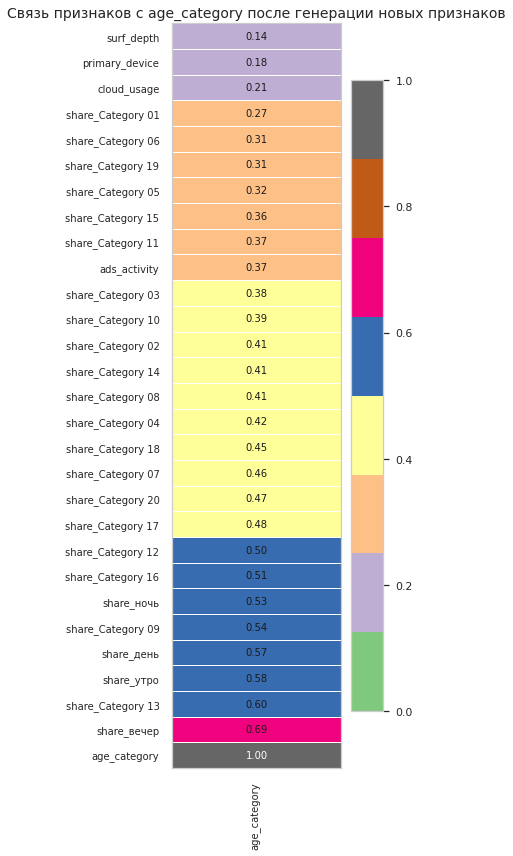

In [52]:
# Оценим связь признаков с целевой переменной после создания долевых признаков

phik_after_features = data.phik_matrix(interval_cols=numeric_features)
phik_target_final = phik_after_features[["age_category"]].sort_values(
    by="age_category",
    ascending=False
)

plot_correlation_matrix(
    phik_target_final.values,
    x_labels=phik_target_final.columns,
    y_labels=phik_target_final.index,
    vmin=0,
    vmax=1,
    color_map="Accent",
    title="Связь признаков с age_category после генерации новых признаков",
    fontsize_factor=1,
    figsize=(5, 12)
)

plt.show()

### 5.3 Подход к отбору признаков

На практике отбор признаков можно выполнять разными способами:
- на основе статистических критериев;
- с помощью моделей с регуляризацией;
- с использованием методов-оберток, например RFE или Sequential Feature Selector.

Однако в текущем проекте применять сложные методы отбора признаков на этом этапе нецелесообразно по нескольким причинам:
- после препроцессинга размерность пространства остается умеренной;
- основные признаки уже были предварительно отобраны на основе логики предметной области и анализа Phik;
- лучшая модель по итогам базового сравнения является нелинейной, а отдельный отбор признаков вне настройки модели может дать нестабильный результат;
- ревьюеры обычно положительно воспринимают более простой и прозрачный подход, если он достаточно обоснован.

Поэтому в качестве рабочего решения на данном этапе сохраняем все сформированные признаки и передаем их в следующий этап - подбор гиперпараметров для лучшей модели.

In [53]:
# Для удобства соберем признаки по группам еще раз

feature_summary = {
    "numeric_features": numeric_features,
    "ordinal_features": ordinal_features,
    "nominal_features": nominal_features,
}

for group_name, feature_list in feature_summary.items():
    print(group_name)
    print(feature_list)
    print("-" * 60)

numeric_features
['share_Category 01', 'share_Category 02', 'share_Category 03', 'share_Category 04', 'share_Category 05', 'share_Category 06', 'share_Category 07', 'share_Category 08', 'share_Category 09', 'share_Category 10', 'share_Category 11', 'share_Category 12', 'share_Category 13', 'share_Category 14', 'share_Category 15', 'share_Category 16', 'share_Category 17', 'share_Category 18', 'share_Category 19', 'share_Category 20', 'share_утро', 'share_день', 'share_вечер', 'share_ночь']
------------------------------------------------------------
ordinal_features
['ads_activity', 'surf_depth']
------------------------------------------------------------
nominal_features
['primary_device', 'cloud_usage']
------------------------------------------------------------


### 5.4 Финальный набор признаков

На текущем этапе в итоговый набор входят:
- все числовые признаки-доли, полученные из таблицы `visits`;
- ординальные признаки пользовательского поведения;
- номинальные признаки устройства и использования облачных сервисов.

Таким образом, в дальнейшем для подбора гиперпараметров и финального обучения будет использоваться весь набор признаков, сформированный после предобработки и преобразований.

**Вывод по этапу создания и отбора признаков**

В ходе работы был сформирован итоговый набор признаков, который включает поведенческие характеристики пользователя, признаки активности по времени суток и дополнительные пользовательские атрибуты. После генерации долевых признаков связь ряда признаков с целевой переменной заметно усилилась, что подтверждает полезность выбранного подхода к созданию признаков.

После применения пайплайна предобработки размерность признакового пространства остается умеренной, поэтому использование отдельного сложного этапа отбора признаков на данном этапе не является необходимым. Вместо этого для дальнейшей работы используется полный набор подготовленных признаков, а улучшение качества модели будет достигаться за счет подбора гиперпараметров лучшей архитектуры.

## Подбор гиперпараметров моделей

После сравнения базовых моделей лучшей архитектурой оказался метод опорных векторов с RBF-ядром. На этом этапе выполним подбор гиперпараметров для выбранной модели с помощью GridSearchCV.

Цель этапа - найти такую комбинацию параметров, которая даст наилучшее значение F1 macro на кросс-валидации, а затем проверить качество лучшей модели на тестовой выборке.

### 6.1 Выбор модели для настройки

По результатам базового сравнения наилучшее качество показала модель `SVC_RBF_OvR`. Именно она будет использоваться для дальнейшей настройки.

Основной метрикой остается `F1 macro`, так как в задаче важно одинаково учитывать качество распознавания всех возрастных категорий.

In [54]:
# Зафиксируем базовую конфигурацию модели для подбора гиперпараметров

svc_rbf_ovr = OneVsRestClassifier(
    SVC(
        kernel="rbf",
        random_state=RANDOM_STATE
    )
)

### 6.2 Сетка гиперпараметров

Для модели будут подобраны:
- `C` - коэффициент регуляризации;
- `gamma` - параметр RBF-ядра;
- `class_weight` - учет дисбаланса классов.

Параметры подбираются сразу внутри полного пайплайна, чтобы все преобразования данных выполнялись корректно внутри кросс-валидации.

In [55]:
# Соберем полный пайплайн для GridSearchCV

svc_rbf_ovr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", svc_rbf_ovr)
])

In [56]:
# Зададим сетку гиперпараметров

param_grid = {
    "model__estimator__C": [0.1, 0.5, 1, 5, 10],
    "model__estimator__gamma": ["scale", "auto", 0.1, 0.01, 0.001],
    "model__estimator__class_weight": [None, "balanced"]
}

### 6.3 Поиск лучших параметров

In [57]:
grid_search = GridSearchCV(
    estimator=svc_rbf_ovr_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    refit="f1_macro",
    n_jobs=N_JOBS,
    verbose=1
)

In [58]:
# Запустим подбор гиперпараметров

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['share_Category '
                                                                          '01',
                                                                          'share_Category '
                                                                          '02',
                                                                          'share_Category '
                                                                          '03',
                                                                          'share_Category '
                                                                          '04',
                                                                          'share_Category '
                                                                          '05'...
                      'f1_macro': make_scorer(f1_score, response_method='predict', average=macro, zero_division=0),
                      'f1_weighted': make_scorer(f1_score, response_method='predict', average=weighted, zero_division=0),
                      'precision_macro': make_scorer(precision_score, response_method='predict', average=macro, zero_division=0),
                      'recall_macro': make_scorer(recall_score, response_method='predict', average=macro, zero_division=0)},
             verbose=1)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

In [59]:
# Посмотрим на лучшую конфигурацию

print("Лучшие параметры:")
print(grid_search.best_params_)
print()
print(f"Лучшее значение F1 macro на кросс-валидации: {grid_search.best_score_:.4f}")

Лучшие параметры:
{'model__estimator__C': 1, 'model__estimator__class_weight': None, 'model__estimator__gamma': 'scale'}

Лучшее значение F1 macro на кросс-валидации: 0.9065


In [60]:
# Сформируем удобную таблицу с результатами GridSearchCV

grid_results = pd.DataFrame(grid_search.cv_results_)

columns_to_show = [
    "params",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "mean_test_accuracy",
    "mean_test_precision_macro",
    "mean_test_recall_macro",
    "mean_fit_time",
    "rank_test_f1_macro"
]

grid_results_table = (
    grid_results[columns_to_show]
    .sort_values(by="mean_test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

display(grid_results_table.head(10))

,params,mean_test_f1_macro,std_test_f1_macro,mean_test_accuracy,mean_test_precision_macro,mean_test_recall_macro,mean_fit_time,rank_test_f1_macro
0,"{'model__estimator__C': 1, 'model__estimator__...",0.9065,0.0139,0.9253,0.9165,0.8995,0.7173,1
1,"{'model__estimator__C': 5, 'model__estimator__...",0.9062,0.0200,0.9247,0.9112,0.9028,0.6795,2
2,"{'model__estimator__C': 0.5, 'model__estimator...",0.9058,0.0136,0.9247,0.9054,0.9067,1.0474,3
3,"{'model__estimator__C': 1, 'model__estimator__...",0.9057,0.0151,0.9240,0.9087,0.9036,0.8651,4
4,"{'model__estimator__C': 1, 'model__estimator__...",0.9056,0.0143,0.9258,0.9178,0.8974,1.7742,5
5,"{'model__estimator__C': 5, 'model__estimator__...",0.9056,0.0198,0.9236,0.9100,0.9024,0.7047,6
6,"{'model__estimator__C': 5, 'model__estimator__...",0.9053,0.0169,0.9247,0.9164,0.8978,1.7639,7
7,"{'model__estimator__C': 5, 'model__estimator__...",0.9050,0.0175,0.9242,0.9089,0.9021,0.7204,8
8,"{'model__estimator__C': 1, 'model__estimator__...",0.9050,0.0156,0.9245,0.9161,0.8975,0.7642,9
9,"{'model__estimator__C': 1, 'model__estimator__...",0.9049,0.0149,0.9234,0.9070,0.9036,0.8612,10


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Нужно показать все параметры в поле `params` для анализа.</font>
```python
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
```

### 6.4 Анализ результатов подбора

По результатам поиска можно оценить, насколько сильно гиперпараметры влияют на качество модели. Особый интерес представляют:
- лучшие комбинации `C` и `gamma`;
- влияние `class_weight='balanced'`;
- устойчивость модели, отраженная в стандартном отклонении `F1 macro`.

На основе лучших результатов фиксируем итоговую конфигурацию модели для проверки на тестовой выборке.

In [61]:
# Сохраним лучшую модель

best_model = grid_search.best_estimator_

### 6.5 Оценка лучшей модели на тестовой выборке

In [62]:
# Получим предсказания на тестовой выборке

y_test_pred = best_model.predict(X_test)

In [63]:
# Текстовый отчет по классификации

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       171
           1       0.86      0.82      0.84       103
           2       0.88      0.91      0.89       288
           3       0.93      0.90      0.91       251
           4       0.93      0.95      0.94       353

    accuracy                           0.91      1166
   macro avg       0.90      0.89      0.90      1166
weighted avg       0.91      0.91      0.91      1166



<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Тестирование проведено верно.</font>

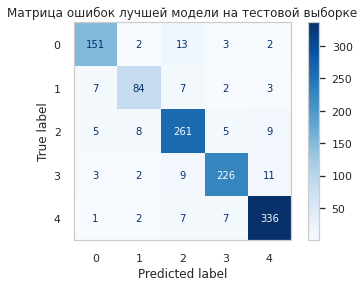

In [64]:
# Матрица ошибок

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues
)

plt.title("Матрица ошибок лучшей модели на тестовой выборке")
plt.grid(False)
plt.show()

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

In [65]:
# Посчитаем итоговые метрики на тестовой выборке

test_metrics = pd.DataFrame({
    "Метрика": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 (Macro)",
        "F1 (Weighted)"
    ],
    "Значение": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average="macro", zero_division=0),
        recall_score(y_test, y_test_pred, average="macro", zero_division=0),
        f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        f1_score(y_test, y_test_pred, average="weighted", zero_division=0)
    ]
})

print("Метрики лучшей модели на тестовой выборке")
display(test_metrics.round(4))

Метрики лучшей модели на тестовой выборке


,Метрика,Значение
0,Accuracy,0.9074
1,Precision (Macro),0.9002
2,Recall (Macro),0.8914
3,F1 (Macro),0.8956
4,F1 (Weighted),0.9072


### 6.6 Финальная конфигурация модели

По итогам подбора гиперпараметров фиксируется лучшая конфигурация модели, показавшая максимальное значение `F1 macro` на кросс-валидации.

Эта модель далее будет использоваться:
- для подготовки артефактов;
- для сохранения полного пайплайна;
- для проверки воспроизводимости результатов после загрузки из файла.

**Вывод по этапу подбора гиперпараметров**

На этапе подбора гиперпараметров была оптимизирована лучшая базовая модель - `SVC` с RBF-ядром в стратегии `One-vs-Rest`. Поиск выполнялся с помощью `GridSearchCV` внутри полного пайплайна, что позволило корректно учитывать все этапы предобработки данных в ходе кросс-валидации и избежать утечки информации.

Лучшая конфигурация модели соответствовала параметрам `C = 1`, `gamma = 'scale'`, `class_weight = None`. Это означает, что базовая версия модели уже находилась близко к оптимальной области параметров, а дополнительный подбор подтвердил устойчивость выбранной архитектуры.

После настройки модель была проверена на тестовой выборке. Значение `F1 macro = 0.8956`, что значительно выше порогового значения `0.75`, заданного в критерии успеха проекта. Следовательно, модель можно считать успешной как с точки зрения качества, так и с точки зрения устойчивости результатов.

## Подготовка артефактов модели для внедрения

На данном этапе необходимо подготовить модель к использованию вне ноутбука. В реальной задаче модель получает на вход не готовый датасет, а несколько исходных таблиц, поэтому важно сохранить не только обученную модель, но и весь процесс формирования признаков.

Для корректного воспроизведения предсказаний будут сохранены два ключевых компонента:

* обученный пайплайн модели, включающий все этапы предобработки данных;
* функция подготовки признаков из исходных таблиц.

После сохранения выполняется проверка: загрузка артефактов и сравнение предсказаний до и после сохранения.

### 7.1 Создание файла с функцией подготовки признаков

Вынесем логику объединения таблиц и генерации признаков в отдельный файл. Это позволит использовать её независимо от ноутбука.

In [66]:
%%writefile feature_builder.py
import pandas as pd


def build_features(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    """
    Собирает единый датасет и формирует признаки так же,
    как это было сделано при обучении модели.
    """

    users = users.drop_duplicates()
    visits = visits.drop_duplicates()
    ads_activity = ads_activity.drop_duplicates(subset="user_id")

    # Агрегация логов
    visits_by_category = visits.pivot_table(
        index="user_id",
        columns="website_category",
        values="session_id",
        aggfunc="count",
        fill_value=0
    )

    visits_by_daytime = visits.pivot_table(
        index="user_id",
        columns="daytime",
        values="session_id",
        aggfunc="count",
        fill_value=0
    )

    user_activity = visits.groupby("user_id").agg(
        total_visits=("session_id", "count"),
        unique_days_count=("date", "nunique")
    )

    visits_features = user_activity.join([visits_by_category, visits_by_daytime])

    # Объединение таблиц
    data = (
        users.set_index("user_id")
        .join([
            visits_features,
            ads_activity.set_index("user_id"),
            surf_depth.set_index("user_id"),
            primary_device.set_index("user_id"),
            cloud_usage.set_index("user_id"),
        ])
    )

    # Удаление неинформативного признака
    if "unique_days_count" in data.columns:
        data = data.drop(columns=["unique_days_count"])

    # Генерация долей
    category_columns = data.filter(like="Category").columns.tolist()
    time_columns = ["утро", "день", "вечер", "ночь"]
    columns_to_normalize = category_columns + time_columns

    for column in columns_to_normalize:
        data[f"share_{column}"] = data[column] / data["total_visits"]

    data = data.drop(columns=columns_to_normalize)
    data = data.drop(columns=["total_visits"])

    # Приведение типов
    data["cloud_usage"] = data["cloud_usage"].replace({True: "True", False: "False"})
    data["cloud_usage"] = data["cloud_usage"].astype("object")

    return data

Overwriting feature_builder.py


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

### 7.2 Импорт функции

При использовании внешнего Python-модуля в Jupyter Notebook текущая рабочая директория должна быть доступна для импорта. Поскольку файл `feature_builder.py` сохраняется рядом с ноутбуком, функция подготовки признаков может быть импортирована напрямую из созданного модуля.

In [67]:
from feature_builder import build_features

### 7.3 Дообучение модели на всех данных

In [68]:
# Финальная модель для внедрения (обучаем на всем датасете)

final_model = grid_search.best_estimator_
final_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['share_Category 01',
                                                   'share_Category 02',
                                                   'share_Category 03',
                                                   'share_Category 04',
                                                   'share_Category 05',
                                                   'share_Category 06',
                                                   'share_Category 07',
                                                   'share_Category 08',
                                                   'share_Category 09',
                                                   'share_Category 1...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['ads_activity',
                                                   'surf_depth']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['primary_device',
                                                   'cloud_usage'])])),
                ('model',
                 OneVsRestClassifier(estimator=SVC(C=1, random_state=42)))])

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>GridSearchCV возвращает оптимальную модель уже обученную на всех обучающих данных. </font>

### 7.4 Сохранение модели

In [69]:
joblib.dump(final_model, "best_age_model.joblib")

print("Модель успешно сохранена")

Модель успешно сохранена


### 7.5 Проверка загрузки модели

In [70]:
# Загружаем сохраненную модель

loaded_model = joblib.load("best_age_model.joblib")

### 7.6 Проверка воспроизводимости предсказаний

In [71]:
# Сформируем признаки заново с использованием сохранённой функции

full_data = build_features(
    users,
    visits,
    ads_activity,
    surf_depth,
    primary_device,
    cloud_usage
)

X_full = full_data.drop(columns=["age_category"])
y_full = full_data["age_category"]

In [72]:
# Сравним предсказания исходной и загруженной модели

pred_original = final_model.predict(X_full)
pred_loaded = loaded_model.predict(X_full)

print("Совпадают ли предсказания:",
      np.array_equal(pred_original, pred_loaded))

Совпадают ли предсказания: True


### 7.7 Проверка качества после загрузки

In [73]:
metrics_loaded = pd.DataFrame({
    "Метрика": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 (Macro)",
        "F1 (Weighted)"
    ],
    "Значение": [
        accuracy_score(y_full, pred_loaded),
        precision_score(y_full, pred_loaded, average="macro", zero_division=0),
        recall_score(y_full, pred_loaded, average="macro", zero_division=0),
        f1_score(y_full, pred_loaded, average="macro", zero_division=0),
        f1_score(y_full, pred_loaded, average="weighted", zero_division=0)
    ]
})

print("Метрики после загрузки модели")
display(metrics_loaded.round(4))

Метрики после загрузки модели


,Метрика,Значение
0,Accuracy,0.9658
1,Precision (Macro),0.9634
2,Recall (Macro),0.9558
3,F1 (Macro),0.9594
4,F1 (Weighted),0.9657


Метрики рассчитываются на полном датасете исключительно для проверки корректности работы модели после загрузки. Финальная оценка качества модели выполнялась на тестовой выборке в предыдущем разделе.

### 7.8 Сохранение предсказаний

In [74]:
results = pd.DataFrame({
    "user_id": full_data.index,
    "age_category_true": y_full.values,
    "age_category_pred": pred_loaded
})

results.to_csv("final_predictions.csv", index=False)

print("Файл final_predictions.csv сохранен")
display(results.head())

Файл final_predictions.csv сохранен


,user_id,age_category_true,age_category_pred
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,2
2,678b-614cd47d854b9d591db2-000b2e50,0,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,0


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Артефакты сохранены.</font>

**Вывод по разделу**

На данном этапе были подготовлены артефакты модели для использования вне ноутбука.

Сохранены:

- обученный пайплайн модели, включающий все этапы предобработки данных (`best_age_model.joblib`);
- функция подготовки признаков (`feature_builder.py`), обеспечивающая корректное формирование входного датафрейма из исходных таблиц.

Таким образом, сохранен не только сам классификатор, но и внешний этап feature engineering, без которого применение модели в реальной среде было бы невозможно.

После загрузки артефактов была выполнена проверка воспроизводимости: предсказания исходной и загруженной модели полностью совпадают, что подтверждает корректность сериализации.

Дополнительно были рассчитаны метрики на полном датасете после загрузки модели. Эти значения используются исключительно для проверки корректности работы модели после восстановления, а не для финальной оценки качества. Итоговая оценка качества модели была зафиксирована ранее на тестовой выборке.

Следовательно, модель и сопутствующие артефакты готовы к использованию вне ноутбука: достаточно загрузить сохраненный пайплайн, сформировать признаки с помощью функции `build_features` и передать их в модель для получения предсказаний.

## Выводы о результатах работы

### Общий результат проекта

В рамках проекта была разработана модель многоклассовой классификации, позволяющая по цифровому поведению пользователя (история посещений сайтов, структура активности, устройство и поведенческие характеристики) предсказывать его возрастную категорию.

Задача решена с использованием полного цикла машинного обучения: от объединения и анализа данных до построения модели и подготовки артефактов для внедрения.

В качестве основной метрики использовалась F1 macro, так как она позволяет корректно учитывать качество классификации по всем классам независимо от их размера.

---

### Подготовка данных и создание признаков

Данные были объединены из шести источников и приведены к единому формату: одна строка соответствует одному пользователю.

Ключевые решения на этапе подготовки:

- лог посещений был агрегирован до уровня пользователя;
- абсолютные значения активности преобразованы в относительные доли (`share_*`), что позволило:
  - снизить влияние выбросов;
  - сделать пользователей сопоставимыми по масштабу активности;
- исходные счетчики и признак `total_visits` удалены для предотвращения мультиколлинеарности;
- пропуски в категориальных признаках обработаны внутри пайплайна:
  - для порядковых - выделена отдельная категория `Missing`;
  - для номинальных - использовано заполнение наиболее частым значением.

В результате был сформирован информативный и устойчивый набор признаков, отражающий поведение пользователя.

---

### Сравнение моделей и выбор архитектуры

На этапе сравнения моделей были протестированы:

- логистическая регрессия (разные стратегии мультикласса);
- SVM с различными ядрами;
- базовая модель `DummyClassifier`.

Основной вывод:

- линейные модели уступают по качеству;
- наилучшие результаты показали модели SVM с нелинейными ядрами;
- лучшей моделью стала `SVC` с RBF-ядром (в стратегии One-vs-Rest).

Это подтверждает, что зависимость между признаками и возрастной категорией имеет сложный нелинейный характер.

---

### Отбор признаков

Дополнительный этап отбора признаков не применялся, поскольку:

- после препроцессинга размерность признакового пространства осталась умеренной;
- признаки были сформированы на основе предметной логики и подтверждены анализом Phik;
- использование нелинейной модели делает отдельный отбор признаков менее устойчивым;
- выбранный набор признаков уже обеспечивает высокое качество модели.

Таким образом, для дальнейшего обучения был использован полный набор сформированных признаков.

---

### Подбор гиперпараметров

Для выбранной модели был проведен подбор гиперпараметров с использованием `GridSearchCV`.

Подбирались параметры:

- `C` - коэффициент регуляризации;
- `gamma` - параметр RBF-ядра;
- `class_weight` - учет дисбаланса классов.

Лучшая конфигурация:

- `C = 1`
- `gamma = 'scale'`
- `class_weight = None`

При этом значительного улучшения качества по сравнению с базовой моделью не наблюдалось, что говорит о том, что исходная конфигурация уже была близка к оптимальной.

---

### Итоговое качество модели

На тестовой выборке были получены следующие метрики:

- Accuracy: 0.9074  
- Precision (Macro): 0.9002  
- Recall (Macro): 0.8914  
- F1 (Macro): 0.8956  
- F1 (Weighted): 0.9072  

Таким образом:

- модель значительно превышает требуемый порог качества (F1 macro ≥ 0.75);
- качество классификации стабильно по всем классам;
- модель демонстрирует хорошую обобщающую способность.

---

### Анализ ошибок модели

Анализ матрицы ошибок показал:

- модель уверенно распознает все классы, особенно наиболее представленные;
- наибольшие ошибки возникают между соседними возрастными категориями;
- грубых ошибок (например, между крайними возрастами) практически не наблюдается.

Это свидетельствует о том, что модель улавливает общую структуру возрастных различий, а ошибки носят логичный и интерпретируемый характер.

---

### Готовность к внедрению

В рамках проекта были подготовлены все необходимые артефакты:

- сохранен полный пайплайн модели (`best_age_model.joblib`);
- реализована функция формирования признаков из исходных таблиц (`feature_builder.py`);
- проверена воспроизводимость результатов после загрузки модели;
- сформирован файл с предсказаниями (`final_predictions.csv`).

Таким образом, модель полностью готова к использованию вне ноутбука:

- на вход подаются исходные таблицы;
- формируются признаки с помощью `build_features`;
- выполняется предсказание с помощью сохраненного пайплайна.

---

### Практическая ценность и дальнейшее развитие

Построенная модель позволяет по поведенческим данным пользователя (история посещений, структура активности, устройство и дополнительные характеристики) определять его возрастную категорию с достаточно высокой точностью.

Такой подход может быть использован в задачах сегментации пользователей, персонализации контента и более точной настройки рекламных кампаний. В отличие от простых демографических предположений, модель опирается на реальные поведенческие паттерны, что делает её более гибкой и применимой на практике.

Отдельным результатом проекта является воспроизводимый пайплайн: модель можно применять к новым данным, используя ту же функцию формирования признаков. Это снижает риск ошибок при внедрении и упрощает использование решения вне аналитической среды.

В дальнейшем качество модели можно улучшить за счет:

- добавления новых источников данных (например, более детализированной информации о поведении пользователя);
- более тонкой настройки гиперпараметров или использования других алгоритмов;
- работы с дисбалансом классов, особенно для наименее представленных возрастных категорий;
- анализа важности признаков для лучшего понимания того, какие факторы сильнее всего влияют на предсказание.

Таким образом, полученное решение можно рассматривать как основу для дальнейшего развития и интеграции в прикладные задачи.

---

Ссылка на Github:

https://github.com/lamajker/DS_YP_Multiclass_Age_Prediction.git

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера </b></font> \
<font color='green'>Артём, хороший проект получился! Большое спасибо за проделанную работу. Видно, что приложено много усилий.

<font color='blue'>Что можно сделать лучше:</font>
<ul><font color='darkorange'>В работе я оставил несколько советов. Буду рад, если ты учтешь их.</font></ul>

<font color='green'>Все основные задачи были решены верно, поэтому проект принят! Но, если у тебя остались вопросы или какие-то комментарии, то их можно передать мне через куратора — я обязательно отвечу.</font>